# IR-Partial-Dispersion Self-Consistent Buchdahl Model Glass


By Ziyi Xiong 2026/4

## Theory

The visible-only model glass uses three descriptors:

$$
(n_d, V_d, \Delta P_{g,F})
$$

Those descriptors strongly constrain visible dispersion, but they do not directly describe the near-IR curve shape. For FSO work near $1.55\,\mu m$, add one IR partial-dispersion descriptor instead of a fixed absolute IR index.

Let:

$$
\lambda_r = 1.55\,\mu m
$$

For the nominal real glass, compute:

$$
dn_{FC} = n_F - n_C = \frac{n_d - 1}{V_d}
$$

and define the IR partial dispersion:

$$
P_r = \frac{n_r - n_d}{dn_{FC}}
$$

where:

$$
n_r = n(\lambda_r)
$$

This is different from storing a fixed $n_r$. During optimization or tolerance, $P_r$ is held as the shape descriptor, while the current IR anchor is recomputed from the current $n_d$ and $V_d$:

$$
n_r^{model} = n_d + P_r\frac{n_d - 1}{V_d}
$$

So if $n_d$ or $V_d$ changes, the whole wavelength-index curve changes, including the index at $\lambda_r$.

The model remains a Buchdahl polynomial:

$$
n(\lambda) = n_d + \sum_{k=1}^{6}\nu_k\omega^k
$$

with:

$$
\omega(\lambda) = \frac{\lambda - \lambda_d}{1 + \alpha(\lambda - \lambda_d)}
$$

The visible model-glass anchors are kept:

$$
n_F - n_C = \frac{n_d - 1}{V_d} = dn_{FC}
$$

$$
P_{g,F} = 0.6438 - 0.001682V_d + \Delta P_{g,F}
$$

$$
n_g - n_F = P_{g,F}\,dn_{FC} = dn_{gF}
$$

The IR partial-dispersion anchor is:

$$
n(\lambda_r) - n_d = P_r\,dn_{FC}
$$

For a 6th-order polynomial, regress the high-order residual coefficients:

$$
\nu_4, \nu_5, \nu_6
$$

Then solve $\nu_1,\nu_2,\nu_3$ exactly from three equations.

The F-C equation is:

$$
\nu_1(\omega_F-\omega_C) + \nu_2(\omega_F^2-\omega_C^2) + \nu_3(\omega_F^3-\omega_C^3)
= dn_{FC} - \sum_{k=4}^{6}\nu_k(\omega_F^k-\omega_C^k)
$$

The g-F equation is:

$$
\nu_1(\omega_g-\omega_F) + \nu_2(\omega_g^2-\omega_F^2) + \nu_3(\omega_g^3-\omega_F^3)
= dn_{gF} - \sum_{k=4}^{6}\nu_k(\omega_g^k-\omega_F^k)
$$

The IR equation is:

$$
\nu_1\omega_r + \nu_2\omega_r^2 + \nu_3\omega_r^3
= P_r\,dn_{FC} - \sum_{k=4}^{6}\nu_k\omega_r^k
$$

Equivalently:

$$
M_3
\begin{bmatrix}
\nu_1 \\
\nu_2 \\
\nu_3
\end{bmatrix}
=
\begin{bmatrix}
b_{FC} \\
b_{gF} \\
b_r
\end{bmatrix}
$$

The runtime regression predicts:

$$
[\nu_4,\nu_5,\nu_6] = \phi(n_d,V_d,\Delta P_{g,F},P_r) A
$$

This keeps the model material independent: $(n_d,V_d,\Delta P_{g,F},P_r)$ define the curve. The nominal catalog glass can still be matched at $\lambda_r$, but later changes to $n_d$ or $V_d$ move the IR index consistently.


In [4]:
from __future__ import annotations

from pathlib import Path
import copy
import importlib.util
import os

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Spectral line wavelengths [um]
LAMBDA_d = 0.5875618   # d-line, yellow He
LAMBDA_g = 0.4358343   # g-line, blue Hg
LAMBDA_F = 0.4861327   # F-line, blue H
LAMBDA_C = 0.6562725   # C-line, red H

## Data Loading


In [5]:
if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    _spec = importlib.util.find_spec("optiland")
    if _spec is None or _spec.origin is None:
        raise RuntimeError(
            "optiland not installed. Run `pip install optiland`, or set "
            "OPTILAND_DB_ROOT to the absolute path of optiland/database."
        )
    DB_ROOT = Path(_spec.origin).parent / "database"

GLASS_ROOT = DB_ROOT / "data-nk" / "glass"
print(GLASS_ROOT)


def sellmeier(wavelength, B1, C1, B2, C2, B3, C3):
    wavelength = np.asarray(wavelength, dtype=np.float64)
    wl2 = wavelength**2
    n2 = 1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3)
    return np.sqrt(n2)


def extract_glass_record(yml_path: Path):
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)

    data_blocks = doc.get("DATA") or []
    if not data_blocks:
        return None
    formula = data_blocks[0]
    if formula.get("type") != "formula 2":
        return None

    coeffs = formula.get("coefficients", "").split()
    if len(coeffs) != 7:
        return None

    wavelength_range = formula.get("wavelength_range", "").strip().split()
    if len(wavelength_range) != 2:
        return None

    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])

    nd = float(sellmeier(LAMBDA_d, B1, C1, B2, C2, B3, C3))
    nF = float(sellmeier(LAMBDA_F, B1, C1, B2, C2, B3, C3))
    nC = float(sellmeier(LAMBDA_C, B1, C1, B2, C2, B3, C3))
    ng = float(sellmeier(LAMBDA_g, B1, C1, B2, C2, B3, C3))

    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None

    vd = (nd - 1.0) / dn_FC
    PgF = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)

    specs = doc.get("SPECS", {})
    return {
        "name": yml_path.stem,
        "catalog": yml_path.parent.name,
        "wavelength_range": (float(wavelength_range[0]), float(wavelength_range[1])),
        "coeffs": {"B1": B1, "C1": C1, "B2": B2, "C2": C2, "B3": B3, "C3": C3},
        "nd": float(nd),
        "vd": float(vd),
        "dPgF": float(dPgF),
        "nd_stored": specs.get("nd"),
        "vd_stored": specs.get("Vd"),
        "dPgF_stored": specs.get("dPgF"),
    }


def load_all_glasses(root=GLASS_ROOT):
    records = []
    for yml_path in sorted(root.glob("*/*.yml")):
        try:
            rec = extract_glass_record(yml_path)
        except Exception:
            rec = None
        if rec is not None:
            records.append(rec)
    return records


glasses = load_all_glasses()
print(f"Loaded {len(glasses)} usable formula-2 glasses")

D:\Msc.Photonics\Master_Thesis\Optiland_Based\optiland_custom\optiland\database\data-nk\glass
Loaded 640 usable formula-2 glasses


In [6]:
# Filter to glasses covering the full model range and remove known bad dPgF records.
glasses_filtered = [
    g for g in glasses
    if g["wavelength_range"][0] <= 0.36501 and g["wavelength_range"][1] >= 2.3
]

before = len(glasses_filtered)
glasses_filtered = [
    g for g in glasses_filtered
    if g["dPgF_stored"] is None or abs(g["dPgF"] - g["dPgF_stored"]) < 0.05
]

print(f"After wavelength filtering and dPgF sanity filter: {len(glasses_filtered)} glasses")
print(f"Removed by dPgF sanity filter: {before - len(glasses_filtered)}")

After wavelength filtering and dPgF sanity filter: 536 glasses
Removed by dPgF sanity filter: 1


## Wavelength Grid And Buchdahl Helpers


In [7]:
wavelengths = np.array([
    0.36501, 0.40466, 0.43583, 0.48613, 0.54607,
    0.58756, 0.58929, 0.6328,  0.64385, 0.65627,
    0.70652, 0.85211, 1.01398, 1.060,   1.52958,
    1.97009, 2.3,
], dtype=np.float64)


def get_indices(glass, wavelengths):
    c = glass["coeffs"]
    return sellmeier(wavelengths, c["B1"], c["C1"], c["B2"], c["C2"], c["B3"], c["C3"])


def buchdahl_omega(lam, alpha, lam_d=LAMBDA_d):
    lam = np.asarray(lam, dtype=np.float64)
    dl = lam - lam_d
    return dl / (1.0 + alpha * dl)


def buchdahl_eval(nd, coeffs, omega):
    omega = np.asarray(omega, dtype=np.float64)
    n = np.full_like(omega, nd, dtype=np.float64)
    for k, coeff in enumerate(coeffs, start=1):
        n += coeff * omega**k
    return n


def feature_vec_20(nd, vd, dPgF):
    return np.array([
        1.0, nd, vd, dPgF, nd**2, vd**2, dPgF**2, nd*vd, nd*dPgF, vd*dPgF,
        nd**3, vd**3, dPgF**3, nd**2*vd, nd**2*dPgF, vd**2*nd, vd**2*dPgF,
        dPgF**2*nd, dPgF**2*vd, nd*vd*dPgF,
    ], dtype=np.float64)


def feature_vec_10(nd, vd, dPgF):
    return np.array([
        1.0, nd, vd, dPgF, nd**2, vd**2, dPgF**2, nd*vd, nd*dPgF, vd*dPgF,
    ], dtype=np.float64)

## IR Partial-Dispersion Solver


In [8]:
LAMBDA_REF = 1.55
ORDER = 6


def get_n_ref(glass, lambda_ref=LAMBDA_REF):
    return float(get_indices(glass, np.array([lambda_ref], dtype=np.float64))[0])


def get_p_ref(glass, lambda_ref=LAMBDA_REF):
    n_ref = get_n_ref(glass, lambda_ref)
    dn_FC = (glass["nd"] - 1.0) / glass["vd"]
    return (n_ref - glass["nd"]) / dn_FC


def feature_vec_ir(nd, vd, dPgF, p_ref):
    """Polynomial features through total degree 3 for four model-glass descriptors."""
    x = np.array([nd, vd, dPgF, p_ref], dtype=np.float64)
    feats = [1.0]
    # degree 1
    feats.extend(x.tolist())
    # degree 2 with replacement
    for i in range(4):
        for j in range(i, 4):
            feats.append(x[i] * x[j])
    # degree 3 with replacement
    for i in range(4):
        for j in range(i, 4):
            for k in range(j, 4):
                feats.append(x[i] * x[j] * x[k])
    return np.array(feats, dtype=np.float64)


def descriptor_ir(glass, lambda_ref=LAMBDA_REF):
    nd = glass["nd"]
    vd = glass["vd"]
    dPgF = glass["dPgF"]
    p_ref = get_p_ref(glass, lambda_ref)
    dn_FC = (nd - 1.0) / vd
    n_ref_model = nd + p_ref * dn_FC
    return nd, vd, dPgF, p_ref, n_ref_model


def solve_nu123_conditioned_ir(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha):
    """Solve nu1,nu2,nu3 conditioned on nu4..nuN using F-C, g-F, and IR partial dispersion."""
    wg = float(buchdahl_omega(LAMBDA_g, alpha))
    wF = float(buchdahl_omega(LAMBDA_F, alpha))
    wC = float(buchdahl_omega(LAMBDA_C, alpha))
    wr = float(buchdahl_omega(lambda_ref, alpha))

    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC
    dn_ref = p_ref * dn_FC

    M = np.array([
        [wF - wC, wF**2 - wC**2, wF**3 - wC**3],
        [wg - wF, wg**2 - wF**2, wg**3 - wF**3],
        [wr, wr**2, wr**3],
    ], dtype=np.float64)

    corr_FC = 0.0
    corr_gF = 0.0
    corr_ref = 0.0
    for power, coeff in enumerate(nu_high, start=4):
        corr_FC += coeff * (wF**power - wC**power)
        corr_gF += coeff * (wg**power - wF**power)
        corr_ref += coeff * wr**power

    rhs = np.array([dn_FC - corr_FC, dn_gF - corr_gF, dn_ref - corr_ref], dtype=np.float64)
    return np.linalg.solve(M, rhs)


def ir_anchor_coeffs(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha):
    nu1, nu2, nu3 = solve_nu123_conditioned_ir(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha)
    return np.concatenate([[nu1, nu2, nu3], np.asarray(nu_high, dtype=np.float64)])


def predict_ir_anchor(nd, vd, dPgF, p_ref, lambda_ref, nu_high, wavelength, alpha):
    omega = buchdahl_omega(wavelength, alpha)
    coeffs = ir_anchor_coeffs(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha)
    return buchdahl_eval(nd, coeffs, omega)


def fit_ir_anchor_nu_high(glass, n_true, omega, alpha, order=ORDER, lambda_ref=LAMBDA_REF):
    """Fit nu4..nu_order while enforcing visible anchors and the IR partial-dispersion anchor exactly."""
    nd, vd, dPgF, p_ref, _ = descriptor_ir(glass, lambda_ref)
    num_high = order - 3
    base = np.zeros(num_high)
    coeff_base = ir_anchor_coeffs(nd, vd, dPgF, p_ref, lambda_ref, base, alpha)
    n_base = buchdahl_eval(nd, coeff_base, omega)

    cols = []
    for j in range(num_high):
        nu_high = np.zeros(num_high)
        nu_high[j] = 1.0
        coeff_j = ir_anchor_coeffs(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha)
        cols.append(buchdahl_eval(nd, coeff_j, omega) - n_base)

    A = np.column_stack(cols)
    target = n_true - n_base
    nu_high, *_ = np.linalg.lstsq(A, target, rcond=None)
    return nu_high


def build_ir_targets(alpha, order=ORDER, lambda_ref=LAMBDA_REF):
    omega = buchdahl_omega(wavelengths, alpha)
    targets = []
    fit_errors = []
    ref_errors = []
    for g in glasses_filtered:
        nd, vd, dPgF, p_ref, n_ref_model = descriptor_ir(g, lambda_ref)
        n_true = get_indices(g, wavelengths)
        nu_high = fit_ir_anchor_nu_high(g, n_true, omega, alpha, order=order, lambda_ref=lambda_ref)
        targets.append(nu_high)
        n_pred = predict_ir_anchor(nd, vd, dPgF, p_ref, lambda_ref, nu_high, wavelengths, alpha)
        fit_errors.append(np.max(np.abs(n_true - n_pred)))
        n_pred_ref = float(predict_ir_anchor(nd, vd, dPgF, p_ref, lambda_ref, nu_high, np.array([lambda_ref]), alpha)[0])
        ref_errors.append(abs(n_pred_ref - n_ref_model))
    return np.vstack(targets), np.array(fit_errors), np.array(ref_errors)


def make_phi_ir(glasses, lambda_ref=LAMBDA_REF):
    return np.vstack([
        feature_vec_ir(g["nd"], g["vd"], g["dPgF"], get_p_ref(g, lambda_ref))
        for g in glasses
    ])


def regress_ir(Y, lambda_ref=LAMBDA_REF):
    Phi = make_phi_ir(glasses_filtered, lambda_ref)
    A = np.linalg.lstsq(Phi, Y, rcond=None)[0]
    return Phi, A


def predict_from_ir_regression(glass, wavelength, alpha, A, lambda_ref=LAMBDA_REF):
    nd, vd, dPgF, p_ref, _ = descriptor_ir(glass, lambda_ref)
    phi = feature_vec_ir(nd, vd, dPgF, p_ref)
    nu_high = phi @ A
    return predict_ir_anchor(nd, vd, dPgF, p_ref, lambda_ref, nu_high, wavelength, alpha)


def runtime_errors_ir(wths, alpha, A, lambda_ref=LAMBDA_REF):
    errs = []
    for g in glasses_filtered:
        n_true = get_indices(g, wths)
        n_pred = predict_from_ir_regression(g, wths, alpha, A, lambda_ref)
        errs.append(np.max(np.abs(n_true - n_pred)))
    return np.array(errs)


def per_wavelength_error_stats_ir(wths, alpha, A, lambda_ref=LAMBDA_REF):
    errors = []
    for g in glasses_filtered:
        n_true = get_indices(g, wths)
        n_pred = predict_from_ir_regression(g, wths, alpha, A, lambda_ref)
        errors.append(np.abs(n_true - n_pred))
    errors = np.vstack(errors)
    return {
        "max": errors.max(axis=0),
        "mean": errors.mean(axis=0),
        "median": np.median(errors, axis=0),
    }


def anchor_report_ir(glass, alpha, A, lambda_ref=LAMBDA_REF):
    nd, vd, dPgF, p_ref, n_ref_model = descriptor_ir(glass, lambda_ref)
    phi = feature_vec_ir(nd, vd, dPgF, p_ref)
    nu_high = phi @ A
    coeffs = ir_anchor_coeffs(nd, vd, dPgF, p_ref, lambda_ref, nu_high, alpha)
    nd_model = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_d, alpha)))
    nF = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_F, alpha)))
    nC = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_C, alpha)))
    ng = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_g, alpha)))
    nr = float(buchdahl_eval(nd, coeffs, buchdahl_omega(lambda_ref, alpha)))
    vd_model = (nd_model - 1.0) / (nF - nC)
    pgf_model = (ng - nF) / (nF - nC)
    dpgf_model = pgf_model - (0.6438 - 0.001682 * vd_model)
    p_ref_model = (nr - nd_model) / (nF - nC)
    return nd_model, vd_model, dpgf_model, p_ref_model, nr, n_ref_model


def find_glass(name):
    key = name.upper()
    return [g for g in glasses_filtered if key in g["name"].upper()]


wth_shift = wavelengths + 0.01
wth_validation = np.unique(np.concatenate([wth_shift, np.array([LAMBDA_REF], dtype=np.float64)]))


## Fit And Regression Matrix


In [9]:
ALPHAS = np.linspace(0.5, 5.0, 60)
fit_rows = []
reg_rows = []
matrices = []
targets = []

for alpha in ALPHAS:
    Y, fit_errors, ref_errors = build_ir_targets(alpha, order=ORDER, lambda_ref=LAMBDA_REF)
    Phi, A = regress_ir(Y, lambda_ref=LAMBDA_REF)
    runtime = runtime_errors_ir(wth_validation, alpha, A, lambda_ref=LAMBDA_REF)
    fit_rows.append((alpha, fit_errors.max(), fit_errors.mean(), np.median(fit_errors), ref_errors.max()))
    reg_rows.append((alpha, runtime.max(), runtime.mean(), np.median(runtime), np.percentile(runtime, 95)))
    matrices.append(A)
    targets.append(Y)

fit_rows = np.array(fit_rows)
reg_rows = np.array(reg_rows)
fit_best_idx = int(np.argmin(fit_rows[:, 1]))
reg_best_idx = int(np.argmin(reg_rows[:, 1]))

ALPHA_IR_FIT_OPT = float(fit_rows[fit_best_idx, 0])
ALPHA_IR_REG_OPT = float(reg_rows[reg_best_idx, 0])
A_IR_FIT_OPT = matrices[fit_best_idx]
A_IR_REG_OPT = matrices[reg_best_idx]
Y_IR_FIT_OPT = targets[fit_best_idx]
Y_IR_REG_OPT = targets[reg_best_idx]

print(f"IR anchor lambda_ref = {LAMBDA_REF:.4f} um")
print(f"Feature matrix shape: {Phi.shape}")
print(f"Target matrix shape: {Y_IR_REG_OPT.shape}")
print(f"Best fit-layer alpha: {ALPHA_IR_FIT_OPT:.4f}, max={fit_rows[fit_best_idx,1]:.3e}, mean={fit_rows[fit_best_idx,2]:.3e}, median={fit_rows[fit_best_idx,3]:.3e}, max_ref={fit_rows[fit_best_idx,4]:.3e}")
print(f"Best runtime alpha:   {ALPHA_IR_REG_OPT:.4f}, max={reg_rows[reg_best_idx,1]:.3e}, mean={reg_rows[reg_best_idx,2]:.3e}, median={reg_rows[reg_best_idx,3]:.3e}, p95={reg_rows[reg_best_idx,4]:.3e}")

pred = Phi @ A_IR_REG_OPT
coeff_err = np.abs(pred - Y_IR_REG_OPT)
print("\nRegression target errors for runtime-opt matrix")
for k in range(coeff_err.shape[1]):
    print(f"  nu{k+4}: max={coeff_err[:, k].max():.3e}, mean={coeff_err[:, k].mean():.3e}")

cases = [
    (f"IR-anchor alpha={ALPHA_IR_FIT_OPT:.3f} fit-opt", ALPHA_IR_FIT_OPT, A_IR_FIT_OPT),
    (f"IR-anchor alpha={ALPHA_IR_REG_OPT:.3f} runtime-opt", ALPHA_IR_REG_OPT, A_IR_REG_OPT),
]


IR anchor lambda_ref = 1.5500 um
Feature matrix shape: (536, 35)
Target matrix shape: (536, 3)
Best fit-layer alpha: 1.4153, max=4.745e-04, mean=2.542e-04, median=2.506e-04, max_ref=4.441e-16
Best runtime alpha:   1.1102, max=1.813e-03, mean=2.213e-04, median=2.035e-04, p95=3.292e-04

Regression target errors for runtime-opt matrix
  nu4: max=2.637e-02, mean=2.599e-03
  nu5: max=5.542e-02, mean=6.725e-03
  nu6: max=1.493e-01, mean=8.482e-03


## Alpha Sweep Plots


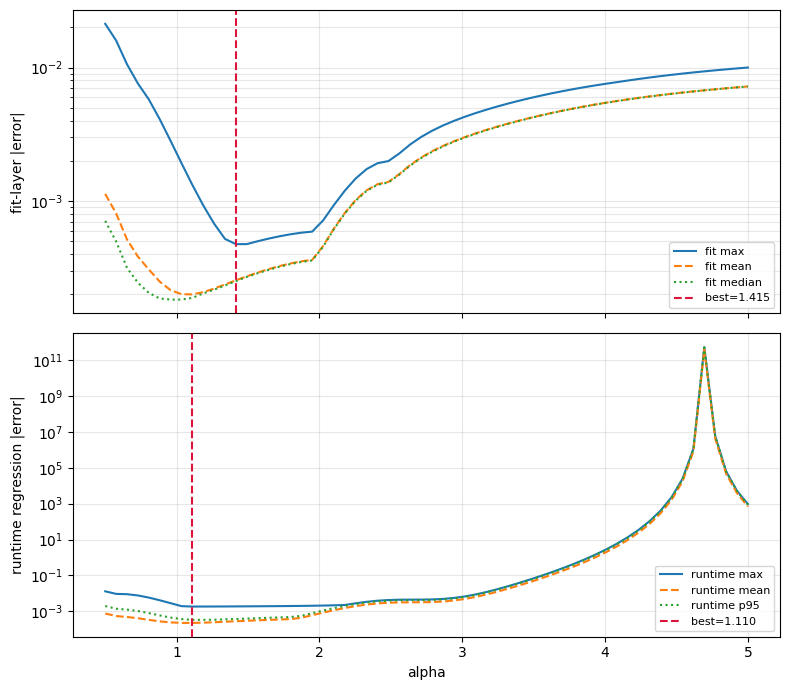

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].semilogy(fit_rows[:, 0], fit_rows[:, 1], label="fit max")
axes[0].semilogy(fit_rows[:, 0], fit_rows[:, 2], ls="--", label="fit mean")
axes[0].semilogy(fit_rows[:, 0], fit_rows[:, 3], ls=":", label="fit median")
axes[0].axvline(ALPHA_IR_FIT_OPT, color="crimson", ls="--", label=f"best={ALPHA_IR_FIT_OPT:.3f}")

axes[1].semilogy(reg_rows[:, 0], reg_rows[:, 1], label="runtime max")
axes[1].semilogy(reg_rows[:, 0], reg_rows[:, 2], ls="--", label="runtime mean")
axes[1].semilogy(reg_rows[:, 0], reg_rows[:, 4], ls=":", label="runtime p95")
axes[1].axvline(ALPHA_IR_REG_OPT, color="crimson", ls="--", label=f"best={ALPHA_IR_REG_OPT:.3f}")

axes[0].set_ylabel("fit-layer |error|")
axes[1].set_ylabel("runtime regression |error|")
axes[1].set_xlabel("alpha")
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## End-To-End Validation


In [11]:
for test_name, wths in [("training wavelengths", wavelengths), ("shifted wavelengths", wth_shift), ("validation incl. lambda_ref", wth_validation)]:
    print("\n" + "="*72)
    print(test_name)
    print("="*72)
    for name, alpha, A in cases:
        errs = runtime_errors_ir(wths, alpha, A, lambda_ref=LAMBDA_REF)
        print(f"{name:<42} max={errs.max():.4e} mean={errs.mean():.4e} median={np.median(errs):.4e} p95={np.percentile(errs,95):.4e}")



training wavelengths
IR-anchor alpha=1.415 fit-opt              max=1.7764e-03 mean=2.7200e-04 median=2.5874e-04 p95=3.6181e-04
IR-anchor alpha=1.110 runtime-opt          max=1.7424e-03 mean=2.1883e-04 median=2.0084e-04 p95=3.2445e-04

shifted wavelengths
IR-anchor alpha=1.415 fit-opt              max=1.8517e-03 mean=2.7488e-04 median=2.5846e-04 p95=3.6628e-04
IR-anchor alpha=1.110 runtime-opt          max=1.8130e-03 mean=2.2130e-04 median=2.0347e-04 p95=3.2923e-04

validation incl. lambda_ref
IR-anchor alpha=1.415 fit-opt              max=1.8517e-03 mean=2.7488e-04 median=2.5846e-04 p95=3.6628e-04
IR-anchor alpha=1.110 runtime-opt          max=1.8130e-03 mean=2.2130e-04 median=2.0347e-04 p95=3.2923e-04


## Per-Wavelength Error


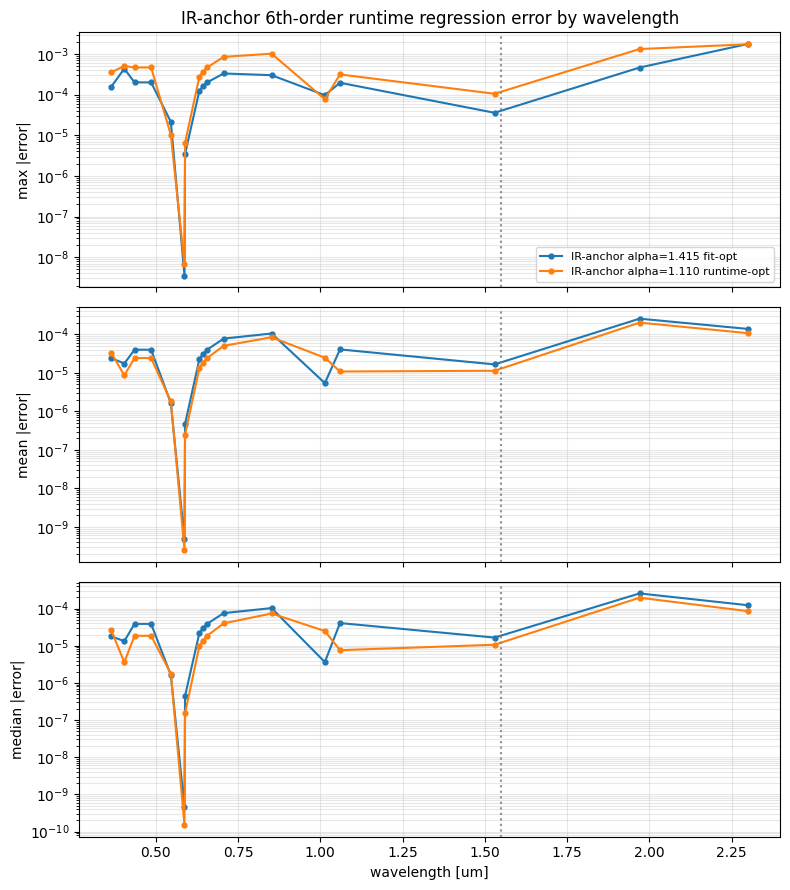

IR-anchor alpha=1.110 runtime-opt
wavelength_um   max_abs_err   mean_abs_err   median_abs_err
     0.36501  3.550313e-04   3.353752e-05     2.608306e-05
     0.40466  5.081680e-04   8.606156e-06     3.598306e-06
     0.43583  4.677909e-04   2.428196e-05     1.849334e-05
     0.48613  4.678883e-04   2.428544e-05     1.849558e-05
     0.54607  1.026524e-05   1.820985e-06     1.787382e-06
     0.58756  6.623290e-09   2.450042e-10     1.489082e-10
     0.58929  6.568131e-06   2.473240e-07     1.523363e-07
     0.63280  2.769965e-04   1.333220e-05     9.768747e-06
     0.64385  3.654748e-04   1.826529e-05     1.368340e-05
     0.65627  4.678422e-04   2.428317e-05     1.849388e-05
     0.70652  8.523214e-04   5.027784e-05     3.995924e-05
     0.85211  1.021042e-03   8.416240e-05     7.368712e-05
     1.01398  7.741182e-05   2.473845e-05     2.487988e-05
     1.06000  3.148081e-04   1.086127e-05     7.589347e-06
     1.52958  1.054464e-04   1.133778e-05     1.063560e-05
     1.97009  1.32838

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
stat_names = ["max", "mean", "median"]
for name, alpha, A in cases:
    stats = per_wavelength_error_stats_ir(wavelengths, alpha, A, lambda_ref=LAMBDA_REF)
    for ax, stat_name in zip(axes, stat_names):
        ax.semilogy(wavelengths, stats[stat_name], marker="o", ms=3.5, label=name)
        ax.axvline(LAMBDA_REF, color="gray", ls=":", alpha=0.6)
        ax.set_ylabel(f"{stat_name} |error|")
        ax.grid(True, which="both", alpha=0.3)
axes[-1].set_xlabel("wavelength [um]")
axes[0].set_title("IR-anchor 6th-order runtime regression error by wavelength")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

name, alpha, A = cases[-1]
stats = per_wavelength_error_stats_ir(wavelengths, alpha, A, lambda_ref=LAMBDA_REF)
print(name)
print("wavelength_um   max_abs_err   mean_abs_err   median_abs_err")
for w, max_err, mean_err, med_err in zip(wavelengths, stats["max"], stats["mean"], stats["median"]):
    print(f"{w:12.5f} {max_err:13.6e} {mean_err:14.6e} {med_err:16.6e}")


## H-LAF3B Diagnostic


In [13]:
matches = find_glass("H-LAF3B")
if matches:
    g = matches[0]
    nd, vd, dPgF, p_ref, n_ref_model = descriptor_ir(g, LAMBDA_REF)
    n_ref_real = get_n_ref(g, LAMBDA_REF)
    print(g["catalog"], g["name"])
    print(f"true n({LAMBDA_REF:.2f}): {n_ref_real:.10f}")
    print(f"P_ref = (n_ref - nd) / (nF - nC) = {p_ref:+.10e}")
    print(f"recomputed n_ref from nd,Vd,P_ref = {n_ref_model:.10f}")

    # Demonstrate the intended model-material behavior: changing nd changes n_ref_model.
    nd_demo = nd + 1e-4
    n_ref_demo = nd_demo + p_ref * ((nd_demo - 1.0) / vd)
    print(f"if nd increases by 1e-4, recomputed n_ref becomes {n_ref_demo:.10f}")

    for name, alpha, A in cases:
        phi = feature_vec_ir(nd, vd, dPgF, p_ref)
        nu_high = phi @ A
        n_pred_ref = float(predict_ir_anchor(nd, vd, dPgF, p_ref, LAMBDA_REF, nu_high, np.array([LAMBDA_REF]), alpha)[0])
        n_pred_155 = float(predict_ir_anchor(nd, vd, dPgF, p_ref, LAMBDA_REF, nu_high, np.array([1.55]), alpha)[0])
        print("\n" + name)
        print(f"  n(lambda_ref)={n_pred_ref:.10f}, err={n_pred_ref - n_ref_model:+.4e}")
        print(f"  n(1.55)={n_pred_155:.10f}, err={n_pred_155 - get_n_ref(g, 1.55):+.4e}")
        print("  predicted nu4..nu6 =", np.array2string(nu_high, precision=6, suppress_small=False))


cdgm H-LAF3B
true n(1.55): 1.7185450039
P_ref = (n_ref - nd) / (nF - nC) = -1.5361903054e+00
recomputed n_ref from nd,Vd,P_ref = 1.7185450039
if nd increases by 1e-4, recomputed n_ref becomes 1.7186415825

IR-anchor alpha=1.415 fit-opt
  n(lambda_ref)=1.7185450039, err=+0.0000e+00
  n(1.55)=1.7185450039, err=+0.0000e+00
  predicted nu4..nu6 = [ 0.18411  -0.12593  -0.772664]

IR-anchor alpha=1.110 runtime-opt
  n(lambda_ref)=1.7185450039, err=+0.0000e+00
  n(1.55)=1.7185450039, err=+0.0000e+00
  predicted nu4..nu6 = [ 0.238502 -0.258308 -0.083633]


## H-LAF3B Perturbed Descriptor Test

This checks the model-material behavior when the descriptors are changed while the IR partial-dispersion descriptor `P_ref` is held fixed.


In [14]:
matches = find_glass("H-LAF3B")
if matches:
    g = matches[0]
    nd, vd, dPgF, p_ref, n_ref_nominal = descriptor_ir(g, LAMBDA_REF)

    nd_pert = nd + 0.0005
    vd_pert = vd * 1.005
    n_ref_pert = nd_pert + p_ref * ((nd_pert - 1.0) / vd_pert)

    print(g["catalog"], g["name"])
    print(f"nominal nd={nd:.10f}, Vd={vd:.10f}, P_ref={p_ref:+.10e}")
    print(f"perturbed nd={nd_pert:.10f}, Vd={vd_pert:.10f}")
    print(f"nominal recomputed n({LAMBDA_REF:.2f})={n_ref_nominal:.10f}")
    print(f"perturbed recomputed n({LAMBDA_REF:.2f})={n_ref_pert:.10f}")
    print(f"delta n_ref={n_ref_pert - n_ref_nominal:+.6e}")

    for name, alpha, A in cases:
        phi_nom = feature_vec_ir(nd, vd, dPgF, p_ref)
        nu_nom = phi_nom @ A
        n_nom = float(predict_ir_anchor(nd, vd, dPgF, p_ref, LAMBDA_REF, nu_nom, np.array([LAMBDA_REF]), alpha)[0])

        phi_pert = feature_vec_ir(nd_pert, vd_pert, dPgF, p_ref)
        nu_pert = phi_pert @ A
        n_pert = float(predict_ir_anchor(nd_pert, vd_pert, dPgF, p_ref, LAMBDA_REF, nu_pert, np.array([LAMBDA_REF]), alpha)[0])

        print("\n" + name)
        print(f"  nominal model n({LAMBDA_REF:.2f})={n_nom:.10f}")
        print(f"  perturbed model n({LAMBDA_REF:.2f})={n_pert:.10f}")
        print(f"  model delta={n_pert - n_nom:+.6e}")
        print(f"  anchor target delta={n_ref_pert - n_ref_nominal:+.6e}")
        print("  perturbed nu4..nu6 =", np.array2string(nu_pert, precision=6, suppress_small=False))


cdgm H-LAF3B
nominal nd=1.7439998979, Vd=44.9000270317, P_ref=-1.5361903054e+00
perturbed nd=1.7444998979, Vd=45.1245271668
nominal recomputed n(1.55)=1.7185450039
perturbed recomputed n(1.55)=1.7191546235
delta n_ref=+6.096196e-04

IR-anchor alpha=1.415 fit-opt
  nominal model n(1.55)=1.7185450039
  perturbed model n(1.55)=1.7191546235
  model delta=+6.096196e-04
  anchor target delta=+6.096196e-04
  perturbed nu4..nu6 = [ 0.18183  -0.122992 -0.769035]

IR-anchor alpha=1.110 runtime-opt
  nominal model n(1.55)=1.7185450039
  perturbed model n(1.55)=1.7191546235
  model delta=+6.096196e-04
  anchor target delta=+6.096196e-04
  perturbed nu4..nu6 = [ 0.235194 -0.25238  -0.086277]


## H-LAF3B Nominal And Perturbed Curves

This overlays the original catalog curve with the IR-partial model curve before and after descriptor perturbation.


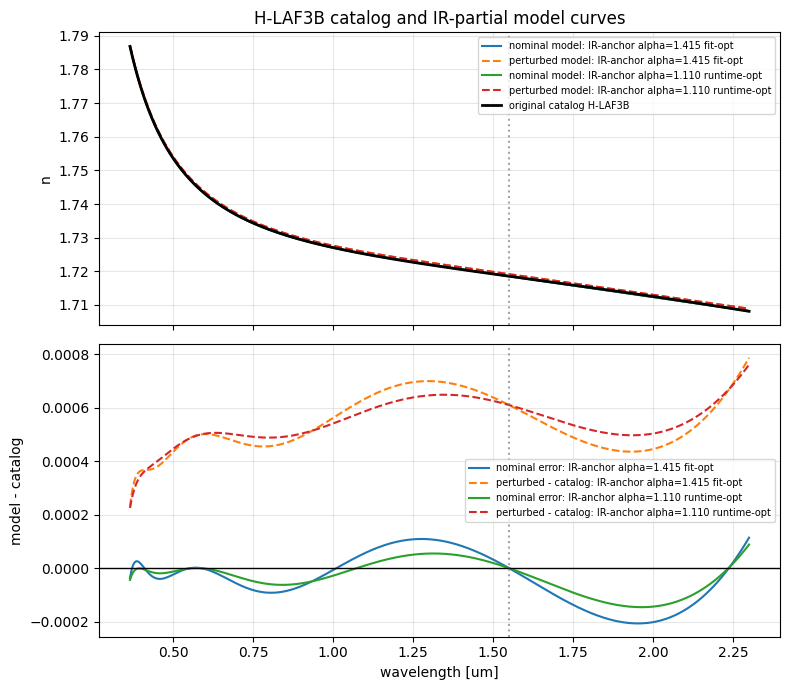

perturbation: nd += 0.0005, Vd *= 1.005, P_ref fixed at -1.536190e+00


In [15]:
matches = find_glass("H-LAF3B")
if matches:
    g = matches[0]
    nd, vd, dPgF, p_ref, n_ref_nominal = descriptor_ir(g, LAMBDA_REF)
    nd_pert = nd + 0.0005
    vd_pert = vd * 1.005

    # Dense plotting grid clipped to this glass's valid Sellmeier range.
    wl_min = max(g["wavelength_range"][0], 0.36501)
    wl_max = min(g["wavelength_range"][1], 2.3)
    wl_plot = np.linspace(wl_min, wl_max, 400)
    n_catalog = get_indices(g, wl_plot)

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    for name, alpha, A in cases:
        phi_nom = feature_vec_ir(nd, vd, dPgF, p_ref)
        nu_nom = phi_nom @ A
        n_nom_model = predict_ir_anchor(nd, vd, dPgF, p_ref, LAMBDA_REF, nu_nom, wl_plot, alpha)

        phi_pert = feature_vec_ir(nd_pert, vd_pert, dPgF, p_ref)
        nu_pert = phi_pert @ A
        n_pert_model = predict_ir_anchor(nd_pert, vd_pert, dPgF, p_ref, LAMBDA_REF, nu_pert, wl_plot, alpha)

        axes[0].plot(wl_plot, n_nom_model, label=f"nominal model: {name}")
        axes[0].plot(wl_plot, n_pert_model, ls="--", label=f"perturbed model: {name}")
        axes[1].plot(wl_plot, n_nom_model - n_catalog, label=f"nominal error: {name}")
        axes[1].plot(wl_plot, n_pert_model - n_catalog, ls="--", label=f"perturbed - catalog: {name}")

    axes[0].plot(wl_plot, n_catalog, color="black", lw=2.0, label="original catalog H-LAF3B")
    axes[0].axvline(LAMBDA_REF, color="gray", ls=":", alpha=0.7)
    axes[1].axhline(0.0, color="black", lw=1.0)
    axes[1].axvline(LAMBDA_REF, color="gray", ls=":", alpha=0.7)

    axes[0].set_ylabel("n")
    axes[1].set_ylabel("model - catalog")
    axes[1].set_xlabel("wavelength [um]")
    axes[0].set_title("H-LAF3B catalog and IR-partial model curves")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    print(f"perturbation: nd += 0.0005, Vd *= 1.005, P_ref fixed at {p_ref:+.6e}")


## Anchor Consistency Test


In [16]:
for name, alpha, A in cases:
    max_nd = 0.0
    max_vd = 0.0
    max_dpgf = 0.0
    max_pref = 0.0
    max_ref = 0.0
    for g in glasses_filtered:
        nd_m, vd_m, dpgf_m, pref_m, nr_m, nr_target = anchor_report_ir(g, alpha, A, lambda_ref=LAMBDA_REF)
        nd, vd, dPgF, p_ref, _ = descriptor_ir(g, LAMBDA_REF)
        max_nd = max(max_nd, abs(nd_m - nd))
        max_vd = max(max_vd, abs(vd_m - vd))
        max_dpgf = max(max_dpgf, abs(dpgf_m - dPgF))
        max_pref = max(max_pref, abs(pref_m - p_ref))
        max_ref = max(max_ref, abs(nr_m - nr_target))
    print(f"{name:<42} max anchor errors: nd={max_nd:.3e}, Vd={max_vd:.3e}, dPgF={max_dpgf:.3e}, P_ref={max_pref:.3e}, n_ref={max_ref:.3e}")


IR-anchor alpha=1.415 fit-opt              max anchor errors: nd=0.000e+00, Vd=6.906e-12, dPgF=1.232e-13, P_ref=1.679e-13, n_ref=4.441e-16
IR-anchor alpha=1.110 runtime-opt          max anchor errors: nd=0.000e+00, Vd=5.954e-12, dPgF=9.803e-14, P_ref=1.323e-13, n_ref=4.441e-16


## Save IR Partial-Dispersion Matrices


In [17]:
np.save("regression_buchdahl_ir_partial_nu456_35dim_fit_opt.npy", A_IR_FIT_OPT)
np.save("regression_buchdahl_ir_partial_nu456_35dim_runtime_opt.npy", A_IR_REG_OPT)

with open("regression_buchdahl_ir_partial_metadata.txt", "w", encoding="utf-8") as f:
    f.write(f"LAMBDA_REF={LAMBDA_REF:.12g}\n")
    f.write(f"ORDER={ORDER}\n")
    f.write("features=polynomial total degree <=3 of nd,vd,dPgF,P_ref\n")
    f.write("P_ref=(n(lambda_ref)-nd)/((nd-1)/Vd)\n")
    f.write("targets=nu4..nu6\n")
    f.write(f"ALPHA_IR_FIT_OPT={ALPHA_IR_FIT_OPT:.12g}\n")
    f.write(f"ALPHA_IR_REG_OPT={ALPHA_IR_REG_OPT:.12g}\n")
    f.write("anchors=d,F,C,g plus IR partial dispersion P_ref\n")

print("Saved IR-partial-dispersion regression matrices and metadata.")
print(f"ALPHA_IR_FIT_OPT = {ALPHA_IR_FIT_OPT:.6f}")
print(f"ALPHA_IR_REG_OPT = {ALPHA_IR_REG_OPT:.6f}")


Saved IR-partial-dispersion regression matrices and metadata.
ALPHA_IR_FIT_OPT = 1.415254
ALPHA_IR_REG_OPT = 1.110169


## Runtime Formula For `ModelMaterial`

An IR-aware `ModelMaterial` should accept an IR partial-dispersion descriptor, not a fixed absolute IR index:

```python
ModelMaterial(nd=..., vd=..., dPgF=..., p_ref=..., lambda_ref=1.55)
```

When converting a real catalog glass to this model, compute:

$$
P_r = \frac{n_{real}(\lambda_r)-n_d}{(n_d-1)/V_d}
$$

Runtime steps:

1. Compute $dn_{FC} = (n_d-1)/V_d$ from the current model parameters.
2. Compute the current IR anchor as $n_r^{model} = n_d + P_r\,dn_{FC}$.
3. Build features $\phi(n_d,V_d,\Delta P_{g,F},P_r)$.
4. Predict $[\nu_4,\nu_5,\nu_6]$ from the saved regression matrix.
5. Solve $\nu_1,\nu_2,\nu_3$ from the F-C, g-F, and IR partial-dispersion equations.
6. Evaluate the 6th-order Buchdahl polynomial.

This preserves the visible model-glass anchors and preserves $P_r$. It does **not** freeze $n(\lambda_r)$ to the original real glass value; if $n_d$ or $V_d$ changes, $n(\lambda_r)$ changes consistently.
